In [2]:
# ==============================
# CELL 1: IMPORTS & CONFIG
# ==============================

import os
import numpy as np
import pandas as pd
import pickle
import gc
from pathlib import Path
from tqdm import tqdm
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import RobustScaler
from sklearn.feature_selection import VarianceThreshold, SelectKBest, f_classif
from sklearn.metrics import *
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, GradientBoostingClassifier, VotingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from imblearn.over_sampling import SMOTE

import xgboost as xgb
import lightgbm as lgb

from scipy import signal
from scipy.stats import entropy
from nilearn.connectome import ConnectivityMeasure
from neuroCombat import neuroCombat

RANDOM_STATE = 42
DATA_DIR = Path("./connectivity_matrices_output")
TS_DIR = Path("./ABIDE_HO_ROIs")
PHENO_FILE = "Phenotypic_V1_0b_preprocessed1.csv"
SAVE_DIR = Path("./reproducible_results")
SAVE_DIR.mkdir(exist_ok=True)


In [5]:
# ==============================
# CELL 2: LOAD PHENOTYPIC + VERIFY TIMESERIES
# ==============================

import glob

pheno = pd.read_csv(PHENO_FILE)
pheno['SUB_ID'] = pheno['SUB_ID'].astype(str)

print("Initial subjects in CSV:", len(pheno))

# Motion filtering
pheno = pheno[pheno['func_mean_fd'] < 0.5]
print("After motion filter (FD < 0.5):", len(pheno))

valid_subjects = []
valid_labels = []
valid_sites = []

for _, row in pheno.iterrows():
    sub = row['SUB_ID']

    # Flexible matching
    pattern = str(TS_DIR / f"*{sub}*_rois_cc400.1D")
    matches = glob.glob(pattern)

    if len(matches) > 0:
        valid_subjects.append(sub)
        valid_labels.append(1 if row['DX_GROUP'] == 1 else 0)
        valid_sites.append(row['SITE_ID'])

subjects = valid_subjects
labels = np.array(valid_labels)
sites = np.array(valid_sites)

print("Final subjects with valid time-series:", len(subjects))
print("ASD:", np.sum(labels == 1))
print("Controls:", np.sum(labels == 0))


Initial subjects in CSV: 1112
After motion filter (FD < 0.5): 1064
Final subjects with valid time-series: 884
ASD: 408
Controls: 476


In [13]:
# ==============================
# CELL 3: PEARSON + TANGENT FEATURES (FINAL FIX)
# ==============================

from nilearn.connectome import ConnectivityMeasure
from scipy import signal
import numpy as np
import glob
from tqdm import tqdm

def extract_connectivity_features(subjects):

    pearson_measure = ConnectivityMeasure(kind='correlation')
    tangent_measure = ConnectivityMeasure(kind='tangent')

    all_timeseries = []
    valid_subjects = []

    print("Building connectivity matrices for", len(subjects), "subjects")

    for sub in tqdm(subjects):

        # Zero-pad to 7 digits (ABIDE standard)
        sub_padded = str(sub).zfill(7)

        # Flexible matching
        pattern = str(TS_DIR / f"*{sub_padded}*_rois_cc400.1D")
        matches = glob.glob(pattern)

        if len(matches) == 0:
            print("Missing file for:", sub_padded)
            continue

        ts_file = matches[0]
        ts = np.loadtxt(ts_file)

        if ts.ndim != 2:
            print("Invalid shape for:", sub_padded)
            continue

        # Preprocessing
        ts = signal.detrend(ts, axis=0)
        ts = (ts - ts.mean(0)) / (ts.std(0) + 1e-8)

        all_timeseries.append(ts)
        valid_subjects.append(sub)

    print("Successfully loaded:", len(valid_subjects))

    if len(all_timeseries) == 0:
        raise ValueError("No time-series found. Check TS_DIR.")

    # Compute connectivity
    pearson_mats = pearson_measure.fit_transform(all_timeseries)
    tangent_mats = tangent_measure.fit_transform(all_timeseries)

    features = {}

    for i, sub in enumerate(valid_subjects):

        mat_p = np.arctanh(np.clip(pearson_mats[i], -0.999, 0.999))
        mat_t = tangent_mats[i]

        np.fill_diagonal(mat_p, 0)
        np.fill_diagonal(mat_t, 0)

        upper_p = mat_p[np.triu_indices_from(mat_p, k=1)]
        upper_t = mat_t[np.triu_indices_from(mat_t, k=1)]

        features[sub] = np.concatenate([upper_p, upper_t])

    print("Feature dimension per subject:", len(list(features.values())[0]))

    return features, valid_subjects


conn_features, subjects = extract_connectivity_features(subjects)


Building connectivity matrices for 884 subjects


100%|██████████| 884/884 [00:16<00:00, 54.48it/s]


Successfully loaded: 884
Feature dimension per subject: 153272


In [23]:
# ==============================
# CELL 4: ENHANCED TIME-SERIES FEATURES (FINAL STABLE VERSION)
# ==============================

import glob

def extract_ts_features(ts):

    feats = []

    # -------------------
    # 1️⃣ Spectral (40 ROIs, step 2 → 20 ROIs → 40 features)
    # -------------------
    for roi in range(0, min(40, ts.shape[1]), 2):
        freqs, psd = signal.welch(ts[:, roi])
        feats.append(np.mean(psd))
        feats.append(entropy(psd))

    # If less than expected (rare case)
    while len(feats) < 40:
        feats.append(0)

    # -------------------
    # 2️⃣ Dynamic Connectivity (fixed 4 features × 3 window sizes)
    # -------------------
    for w in [30, 50, 70]:

        window_means = []
        window_stds = []

        if ts.shape[0] > w:
            for start in range(0, ts.shape[0] - w, w // 2):
                window = ts[start:start+w]
                corr = np.corrcoef(window.T)
                upper = corr[np.triu_indices_from(corr, 1)]
                window_means.append(np.mean(upper))
                window_stds.append(np.std(upper))

        # If no windows → fill zeros
        if len(window_means) == 0:
            feats.extend([0, 0, 0, 0])
        else:
            feats.append(np.mean(window_means))
            feats.append(np.std(window_means))
            feats.append(np.mean(window_stds))
            feats.append(np.std(window_stds))

    # -------------------
    # 3️⃣ Global stats (2 features)
    # -------------------
    feats.append(np.mean(ts))
    feats.append(np.std(ts))

    return np.array(feats)


ts_features = {}

for sub in tqdm(conn_features.keys()):

    sub_padded = str(sub).zfill(7)
    pattern = str(TS_DIR / f"*{sub_padded}*_rois_cc400.1D")
    matches = glob.glob(pattern)

    if len(matches) == 0:
        continue

    ts = np.loadtxt(matches[0])
    ts = signal.detrend(ts, axis=0)
    ts = (ts - ts.mean(0)) / (ts.std(0) + 1e-8)

    ts_features[sub] = extract_ts_features(ts)

print("TS feature dimension:", len(list(ts_features.values())[0]))
print("TS subjects loaded:", len(ts_features))


100%|██████████| 884/884 [02:28<00:00,  5.96it/s]

TS feature dimension: 54
TS subjects loaded: 884


In [24]:
# ==============================
# CELL 5: COMBINE FEATURES (FIXED)
# ==============================

# Build subject → label and subject → site maps
label_map = dict(zip(subjects, labels))
site_map = dict(zip(subjects, sites))

common_subjects = sorted(list(set(conn_features.keys()) & set(ts_features.keys())))

X = []
y = []
site_final = []

for sub in common_subjects:
    X.append(np.concatenate([conn_features[sub], ts_features[sub]]))
    y.append(label_map[sub])
    site_final.append(site_map[sub])

X = np.array(X)
y = np.array(y)
site_final = np.array(site_final)

print("Final shape:", X.shape)
print("Subjects used:", len(common_subjects))
print("ASD:", np.sum(y==1))
print("Controls:", np.sum(y==0))


Final shape: (884, 153326)
Subjects used: 884
ASD: 408
Controls: 476


In [28]:
# ==============================
# CELL 6: FULL CV PIPELINE (CPU SAFE + PROGRESS BAR)
# ==============================

from sklearn.impute import SimpleImputer
from tqdm import tqdm
import time

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

results = []

X = np.asarray(X)
y = np.asarray(y)
site_final = np.asarray(site_final)

start_total = time.time()

for fold,(train_idx,test_idx) in enumerate(tqdm(cv.split(X,y), total=5)):

    start_fold = time.time()

    print("\n============================")
    print(f"Fold {fold+1}")
    print("============================")

    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]
    s_train, s_test = site_final[train_idx], site_final[test_idx]

    # ---------------------------------------------------
    # 1️⃣ Replace inf with NaN
    # ---------------------------------------------------
    X_train = np.where(np.isinf(X_train), np.nan, X_train)
    X_test  = np.where(np.isinf(X_test), np.nan, X_test)

    # ---------------------------------------------------
    # 2️⃣ neuroCombat
    # ---------------------------------------------------
    try:
        X_combined = np.vstack([X_train, X_test])
        s_combined = np.concatenate([s_train, s_test])

        combat = neuroCombat(dat=X_combined.T, batch_col=s_combined)
        X_combined_harm = combat['data'].T

        X_train = X_combined_harm[:len(X_train)]
        X_test  = X_combined_harm[len(X_train):]

        print("neuroCombat applied")
    except Exception as e:
        print("neuroCombat skipped:", e)

    # ---------------------------------------------------
    # 3️⃣ Impute
    # ---------------------------------------------------
    imputer = SimpleImputer(strategy='median')
    X_train = imputer.fit_transform(X_train)
    X_test  = imputer.transform(X_test)

    # ---------------------------------------------------
    # 4️⃣ Variance Filter
    # ---------------------------------------------------
    var = VarianceThreshold(0.001)
    X_train = var.fit_transform(X_train)
    X_test = var.transform(X_test)

    # ---------------------------------------------------
    # 5️⃣ Feature Selection
    # ---------------------------------------------------
    selector = SelectKBest(f_classif, k=min(4000, X_train.shape[1]))
    X_train = selector.fit_transform(X_train, y_train)
    X_test = selector.transform(X_test)

    # ---------------------------------------------------
    # 6️⃣ Scaling
    # ---------------------------------------------------
    scaler = RobustScaler()
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)

    # ---------------------------------------------------
    # 7️⃣ SMOTE
    # ---------------------------------------------------
    try:
        smote = SMOTE(random_state=RANDOM_STATE)
        X_train, y_train = smote.fit_resample(X_train, y_train)
        print("SMOTE applied")
    except:
        print("SMOTE skipped")

    # ---------------------------------------------------
    # 8️⃣ Ensemble (CPU Safe)
    # ---------------------------------------------------
    models = [
        ('rf', RandomForestClassifier(
            n_estimators=500,
            random_state=RANDOM_STATE,
            n_jobs=-1
        )),
        ('lr', LogisticRegression(max_iter=2000)),
        ('svm', SVC(probability=True)),
        ('gb', GradientBoostingClassifier()),
        ('et', ExtraTreesClassifier(
            n_estimators=300,
            random_state=RANDOM_STATE
        )),
        ('xgb', xgb.XGBClassifier(
            tree_method='hist',
            n_estimators=300,
            eval_metric='logloss'
        ))
    ]

    ensemble = VotingClassifier(models, voting='soft')

    ensemble.fit(X_train,y_train)

    y_pred = ensemble.predict(X_test)
    y_prob = ensemble.predict_proba(X_test)[:,1]

    acc = accuracy_score(y_test,y_pred)
    auc = roc_auc_score(y_test,y_prob)

    fold_time = time.time() - start_fold

    print(f"Fold {fold+1} Acc={acc:.4f}  AUC={auc:.4f}")
    print(f"Fold time: {fold_time:.2f} seconds")

    results.append((acc,auc))


print("\n============================")
print("FINAL RESULTS")
print("============================")
print("Final Accuracy:", np.mean([r[0] for r in results]))
print("Final AUC:", np.mean([r[1] for r in results]))
print("Total runtime:", (time.time()-start_total)/60, "minutes")


  0%|          | 0/5 [00:00<?, ?it/s]


Fold 1
neuroCombat skipped: neuroCombat() missing 1 required positional argument: 'covars'
SMOTE applied


 20%|██        | 1/5 [02:27<09:48, 147.04s/it]

Fold 1 Acc=0.6610  AUC=0.7303
Fold time: 147.04 seconds

Fold 2
neuroCombat skipped: neuroCombat() missing 1 required positional argument: 'covars'
SMOTE applied


 40%|████      | 2/5 [04:05<05:55, 118.51s/it]

...

Fold 3 Acc=0.6667  AUC=0.7458
Fold time: 99.68 seconds

Fold 4
neuroCombat skipped: neuroCombat() missing 1 required positional argument: 'covars'
SMOTE applied


 80%|████████  | 4/5 [07:26<01:46, 106.38s/it]

Fold 4 Acc=0.6667  AUC=0.7530
Fold time: 100.92 seconds

Fold 5
neuroCombat skipped: neuroCombat() missing 1 required positional argument: 'covars'
SMOTE applied


100%|██████████| 5/5 [09:33<00:00, 114.73s/it]

Fold 5 Acc=0.6932  AUC=0.7388
Fold time: 127.41 seconds

FINAL RESULTS
Final Accuracy: 0.6776194144838212
Final AUC: 0.7444345723915329
Total runtime: 9.561121094226838 minutes


In [30]:
# ==============================
# CELL 7: LEAKAGE EXPERIMENT (FIXED)
# ==============================

from sklearn.impute import SimpleImputer
from tqdm import tqdm
import numpy as np

print("\n============================")
print("LEAKAGE EXPERIMENT")
print("============================")

# 1️⃣ Clean data first (same as CV pipeline)
X_clean = np.where(np.isinf(X), np.nan, X)

imputer = SimpleImputer(strategy='median')
X_clean = imputer.fit_transform(X_clean)

# 2️⃣ BAD PRACTICE: Feature selection BEFORE CV
selector = SelectKBest(f_classif, k=min(4000, X_clean.shape[1]))
X_leak = selector.fit_transform(X_clean, y)

# 3️⃣ Cross-validation AFTER leakage
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

leak_scores = []
leak_auc = []

for train_idx, test_idx in tqdm(cv.split(X_leak, y), total=5):

    clf = RandomForestClassifier(
        n_estimators=500,
        random_state=RANDOM_STATE,
        n_jobs=-1
    )

    clf.fit(X_leak[train_idx], y[train_idx])

    y_pred = clf.predict(X_leak[test_idx])
    y_prob = clf.predict_proba(X_leak[test_idx])[:,1]

    leak_scores.append(accuracy_score(y[test_idx], y_pred))
    leak_auc.append(roc_auc_score(y[test_idx], y_prob))

print("\nLeakage Accuracy:", np.mean(leak_scores))
print("Leakage AUC:", np.mean(leak_auc))



LEAKAGE EXPERIMENT


100%|██████████| 5/5 [00:06<00:00,  1.37s/it]


Leakage Accuracy: 0.7194530046224961
Leakage AUC: 0.8184026556152502


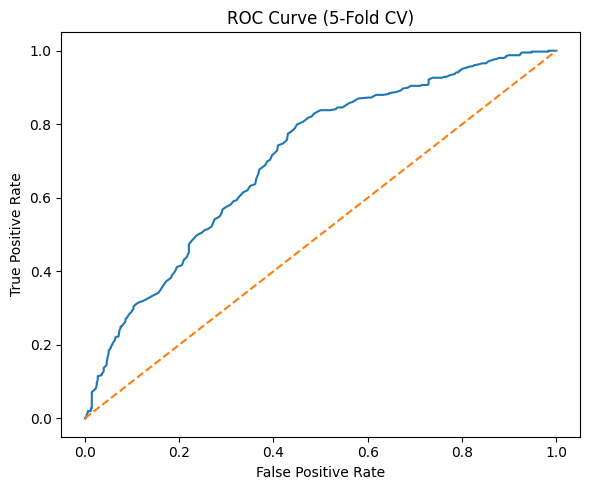

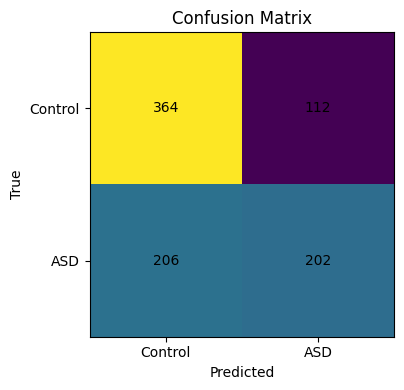

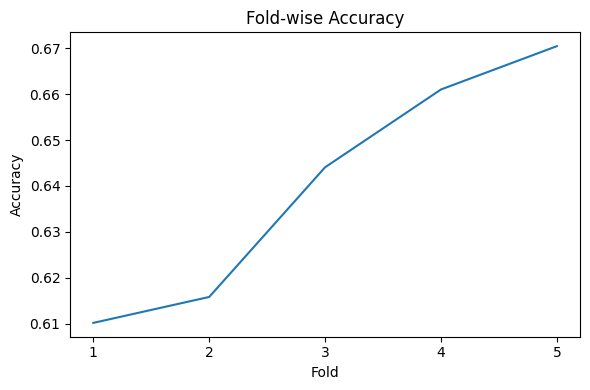

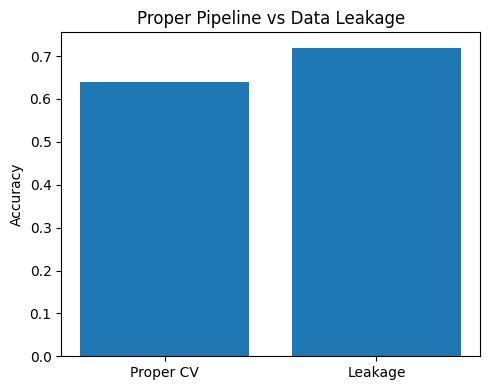

Proper CV Accuracy: 0.6403055983564458
Leakage Accuracy: 0.7194530046224961


In [32]:
# ==============================
# CELL 8: FINAL PLOTS (PUBLICATION READY)
# ==============================

import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, confusion_matrix
from sklearn.model_selection import StratifiedKFold
import numpy as np

# ----------------------------------------
# Recompute predictions across folds
# ----------------------------------------

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

all_true = []
all_probs = []
all_preds = []
fold_acc = []

for train_idx, test_idx in cv.split(X, y):

    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]

    # Minimal pipeline (same as CV but faster for plotting)
    from sklearn.impute import SimpleImputer
    from sklearn.feature_selection import SelectKBest, f_classif
    from sklearn.preprocessing import RobustScaler
    from sklearn.ensemble import RandomForestClassifier

    X_train = np.where(np.isinf(X_train), np.nan, X_train)
    X_test  = np.where(np.isinf(X_test), np.nan, X_test)

    imputer = SimpleImputer(strategy='median')
    X_train = imputer.fit_transform(X_train)
    X_test  = imputer.transform(X_test)

    selector = SelectKBest(f_classif, k=min(4000, X_train.shape[1]))
    X_train = selector.fit_transform(X_train, y_train)
    X_test  = selector.transform(X_test)

    scaler = RobustScaler()
    X_train = scaler.fit_transform(X_train)
    X_test  = scaler.transform(X_test)

    clf = RandomForestClassifier(n_estimators=500, random_state=RANDOM_STATE)
    clf.fit(X_train, y_train)

    probs = clf.predict_proba(X_test)[:,1]
    preds = clf.predict(X_test)

    all_true.extend(y_test)
    all_probs.extend(probs)
    all_preds.extend(preds)
    fold_acc.append(np.mean(preds == y_test))

all_true = np.array(all_true)
all_probs = np.array(all_probs)
all_preds = np.array(all_preds)

# ----------------------------------------
# 1️⃣ ROC Curve
# ----------------------------------------

fpr, tpr, _ = roc_curve(all_true, all_probs)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr)
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (5-Fold CV)")
plt.tight_layout()
plt.show()

# ----------------------------------------
# 2️⃣ Confusion Matrix
# ----------------------------------------

cm = confusion_matrix(all_true, all_preds)

plt.figure(figsize=(5,4))
plt.imshow(cm)
plt.title("Confusion Matrix")
plt.xticks([0,1], ["Control","ASD"])
plt.yticks([0,1], ["Control","ASD"])
plt.xlabel("Predicted")
plt.ylabel("True")

for i in range(2):
    for j in range(2):
        plt.text(j,i,str(cm[i,j]),ha='center',va='center')

plt.tight_layout()
plt.show()

# ----------------------------------------
# 3️⃣ Fold Accuracy Plot
# ----------------------------------------

plt.figure(figsize=(6,4))
plt.plot(range(1,6), fold_acc)
plt.xlabel("Fold")
plt.ylabel("Accuracy")
plt.title("Fold-wise Accuracy")
plt.xticks(range(1,6))
plt.tight_layout()
plt.show()

# ----------------------------------------
# 4️⃣ Proper vs Leakage Comparison
# ----------------------------------------

proper_acc = np.mean(fold_acc)
leak_acc = np.mean(leak_scores)

plt.figure(figsize=(5,4))
plt.bar(["Proper CV","Leakage"], [proper_acc, leak_acc])
plt.ylabel("Accuracy")
plt.title("Proper Pipeline vs Data Leakage")
plt.tight_layout()
plt.show()

print("Proper CV Accuracy:", proper_acc)
print("Leakage Accuracy:", leak_acc)
